# NB05 — Sensitivity Analyses

**Type:** Confirmatory secondary  
**Status:** PENDING EXECUTION  

Pre-specified sensitivity analyses from RESEARCH_PLAN.md §8: tree, lambda, n threshold, response variable,
and geographic restriction.

## Pre-specifications

- Run all sensitivity tests in RESEARCH_PLAN.md §8.1–§8.4
- Report directional consistency with primary result (P1)
- Update INTERPRETATION_TABLE.md §6

## Expected outputs

- INTERPRETATION_TABLE.md §6 filled
- data/05_sensitivity_results.csv


In [1]:
import sys
from pathlib import Path

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts.gene_list_utils import load_gene_list, get_subset, get_ko_set
from scripts.pgls_utils import run_pgls, run_multi_pgls, pgls_results_table, fdr_correct
from scripts.niche_utils import levins_b_std, genus_niche_summary
from scripts.spatial_utils import haversine_join
from scripts.berdl_utils import get_spark_session, load_local_pgls_input

pd.set_option('display.max_rows', 60)
print('Imports OK')

Imports OK


## Analysis Blocks

- **Block 1**: Setup + data loading (bacteria PGLS input; archaea proxied locally from mgnify_mag_ko_density.csv; raw Levins' B approximated via n_envs)
- **Block 2**: S1 λ=0, S2 λ=1, S3 archaea tree, S4 min_n=50, S5 min_n=150, S6 raw Levins' B; S7 Australia-only + S8 N-hemisphere (Spark)
- **Block 3**: Summary table + β comparison figure + save

**Directional consistency check:** Each sensitivity result classified CONSISTENT (β<0, same as P1) or INCONSISTENT (β≥0).


In [2]:
DATA = Path('../data')
FIGS = Path('../figures')
FIGS.mkdir(exist_ok=True)
TREE_BAC = DATA / 'gtdb_bac_genus_pruned.tree'
TREE_ARC = DATA / 'gtdb_arc_genus_pruned.tree'

bac_df = pd.read_csv(DATA / '01_pgls_input_bacteria.csv')
print(f'Bacteria PGLS input: {len(bac_df)} genera')

# Approximate raw Levins' B: B_std = (B-1)/(n_envs-1)  =>  B = B_std*(n_envs-1)+1
genus_trait = pd.read_csv(DATA / 'genus_trait_table.csv')
genus_trait['genus_lower'] = genus_trait['genus_lower'].str.lower().str.strip()
sens_df = bac_df.merge(genus_trait[['genus_lower', 'mean_n_envs']], on='genus_lower', how='left').copy()
sens_df['mean_levins_B_raw'] = sens_df['mean_levins_B_std'] * (sens_df['mean_n_envs'] - 1) + 1
print(f'Raw Levins B (approx): {sens_df["mean_levins_B_raw"].notna().sum()} genera')

# Archaea proxy from local CSVs
traits_all = pd.read_csv(DATA / 'mgnify_mag_metal_traits.csv')
traits_all['genus_lower'] = traits_all['genus'].str.lower().str.strip()
ko_df = pd.read_csv(DATA / 'mgnify_mag_ko_density.csv')
ko_df['genus_lower'] = ko_df['genus'].str.lower().str.strip()
ko_df['ko_per_mb_primary'] = ((ko_df['n_ko_tier1'] + ko_df['n_ko_tier2'])
                               / ko_df['genome_length_mb'])

arc_genera = set(traits_all[traits_all['domain'].str.lower() == 'archaea']['genus_lower'])
arc_ko     = ko_df[ko_df['genus_lower'].isin(arc_genera)]
arc_genus  = arc_ko.groupby('genus_lower', as_index=False).agg(
    ko_per_mb_primary=('ko_per_mb_primary', 'mean'))
arc_df = arc_genus.merge(
    genus_trait[['genus_lower', 'mean_levins_B_std', 'kingdom', 'phylum']],
    on='genus_lower', how='inner'
)
arc_df = arc_df[arc_df['kingdom'].str.lower().str.contains('archaea', na=False)].copy()
if len(arc_df) > 0:
    arc_df['predictor_z'] = ((arc_df['ko_per_mb_primary'] - arc_df['ko_per_mb_primary'].mean())
                              / arc_df['ko_per_mb_primary'].std())
print(f'Archaea data (local approximate): {len(arc_df)} genera')

_SPARK_AVAILABLE = False
_spark = None
try:
    _spark = get_spark_session()
    _SPARK_AVAILABLE = True
    print('Spark available for S7/S8 geographic restriction')
except BaseException as _e:
    print(f'Spark unavailable ({type(_e).__name__}). S7/S8 will be skipped.')

print('Setup complete.')


Bacteria PGLS input: 1574 genera
Raw Levins B (approx): 1574 genera


Archaea data (local approximate): 41 genera


[berdl_utils] JupyterHub SparkSession acquired: 4.0.1
Spark available for S7/S8 geographic restriction
Setup complete.


In [3]:
def _run_s(df, label, fix_lambda=None, min_n=100, response='mean_levins_B_std', tree=None):
    if tree is None:
        tree = TREE_BAC
    v = df.dropna(subset=['predictor_z', response])
    return run_pgls(v, tree, response=response, predictors=['predictor_z'],
                    taxon_col='genus_lower', label=label,
                    fix_lambda=fix_lambda, min_n=min_n)

sens_results = []

# S1: lambda=0 (OLS / star phylogeny)
print('S1: lambda=0')
r = _run_s(bac_df, 'S1_lambda0', fix_lambda=0.0)
r['test'] = 'S1'; r['condition'] = 'lambda=0 (OLS)'
sens_results.append(r)
print(f'  β={r.get("beta", float("nan")):.5f}  p={r.get("p_value", float("nan")):.3e}')

# S2: lambda=1 (Brownian Motion)
print('S2: lambda=1')
r = _run_s(bac_df, 'S2_lambda1', fix_lambda=1.0)
r['test'] = 'S2'; r['condition'] = 'lambda=1 (BM)'
sens_results.append(r)
print(f'  β={r.get("beta", float("nan")):.5f}  p={r.get("p_value", float("nan")):.3e}')

# S3: Archaea tree (local approximate)
print('S3: Archaea tree (local)')
if len(arc_df) >= 30:
    r = _run_s(arc_df, 'S3_archaea', tree=TREE_ARC, min_n=30)
    r['test'] = 'S3'; r['condition'] = 'Archaea tree (local KO approx)'
    sens_results.append(r)
    print(f'  β={r.get("beta", float("nan")):.5f}  p={r.get("p_value", float("nan")):.3e}  n={r.get("n")}')
else:
    print(f'  Insufficient archaea data locally (n={len(arc_df)}); skip or re-run with Spark.')

# S4: min_n=50
print('S4: min_n=50')
r = _run_s(bac_df, 'S4_min50', min_n=50)
r['test'] = 'S4'; r['condition'] = 'min_n=50'
sens_results.append(r)
print(f'  β={r.get("beta", float("nan")):.5f}  p={r.get("p_value", float("nan")):.3e}  n={r.get("n")}')

# S5: min_n=150
print('S5: min_n=150')
r = _run_s(bac_df, 'S5_min150', min_n=150)
r['test'] = 'S5'; r['condition'] = 'min_n=150'
sens_results.append(r)
print(f'  β={r.get("beta", float("nan")):.5f}  p={r.get("p_value", float("nan")):.3e}  n={r.get("n")}')

# S6: Raw Levins' B (approximated)
print("S6: Raw Levins' B (approx)")
n_raw = sens_df['mean_levins_B_raw'].notna().sum()
if n_raw > 100:
    r = _run_s(sens_df, 'S6_raw_levinsB', response='mean_levins_B_raw', min_n=100)
    r['test'] = 'S6'; r['condition'] = "Raw Levins' B ≈ B_std*(n-1)+1"
    sens_results.append(r)
    print(f'  β={r.get("beta", float("nan")):.5f}  p={r.get("p_value", float("nan")):.3e}')
else:
    print(f'  Insufficient raw Levins B data (n={n_raw})')

# S7: Australia only — AusMicrobiome local PGLS input (from microbeatlas_metal_ecology NB13)
print('S7: Australia only')
try:
    MICROBEATLAS = Path('../../microbeatlas_metal_ecology/data')
    aus_raw = pd.read_csv(MICROBEATLAS / 'aus_microbiome/aus_levinsB_pgls_input_fixed.csv')
    aus_raw = aus_raw.rename(columns={'biome_H_std': 'mean_levins_B_std',
                                       'ko_per_mb_total_z': 'predictor_z'})
    aus_bac = aus_raw.merge(bac_df[['genus_lower', 'phylum', 'kingdom']], on='genus_lower', how='left')
    r = _run_s(aus_bac, 'S7_australia', min_n=30)
    r['test'] = 'S7'; r['condition'] = 'Australia only (AusMicrobiome)'
    sens_results.append(r)
    print(f'  β={r.get("beta", float("nan")):.5f}  p={r.get("p_value", float("nan")):.3e}  n={r.get("n")}')
except BaseException as _e:
    print(f'  S7 FAILED: {str(_e)[:80]}')

# S8: Northern Hemisphere only — filter via final_mags_geospatial_traits.csv (microbeatlas)
print('S8: Northern Hemisphere only')
try:
    MICROBEATLAS = DATA.resolve().parent.parent / 'microbeatlas_metal_ecology/data'
    mags_geo = pd.read_csv(MICROBEATLAS / 'final_mags_geospatial_traits.csv',
                           usecols=['genome_id', 'genus', 'lat'])
    mags_geo['genus_lower'] = mags_geo['genus'].str.lower().str.strip()
    genus_lat = (mags_geo.dropna(subset=['lat'])
                 .groupby('genus_lower', as_index=False)
                 .agg(mean_lat=('lat', 'mean')))
    nh_gen = set(genus_lat[genus_lat['mean_lat'] > 0]['genus_lower'])
    nh_bac = bac_df[bac_df['genus_lower'].isin(nh_gen)].copy()
    r = _run_s(nh_bac, 'S8_northhemi', min_n=50)
    r['test'] = 'S8'; r['condition'] = 'N. Hemisphere (mean_lat>0)'
    sens_results.append(r)
    print(f'  β={r.get("beta", float("nan")):.5f}  p={r.get("p_value", float("nan")):.3e}  n={r.get("n")}')
except BaseException as _e:
    print(f'  S8 FAILED: {str(_e)[:80]}')

print(f'\n{len(sens_results)} sensitivity tests complete.')


S1: lambda=0


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  β=-0.03192  p=0.000e+00
S2: lambda=1


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  β=-0.01824  p=3.657e-06
S3: Archaea tree (local)
  β=-0.01826  p=8.356e-02  n=41
S4: min_n=50


...

  β=-0.28583  p=1.110e-11
S7: Australia only


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  β=-0.00171  p=7.550e-01  n=482
S8: Northern Hemisphere only


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  β=-0.03015  p=3.242e-06  n=542

8 sensitivity tests complete.


Saved: data/05_sensitivity_results.csv


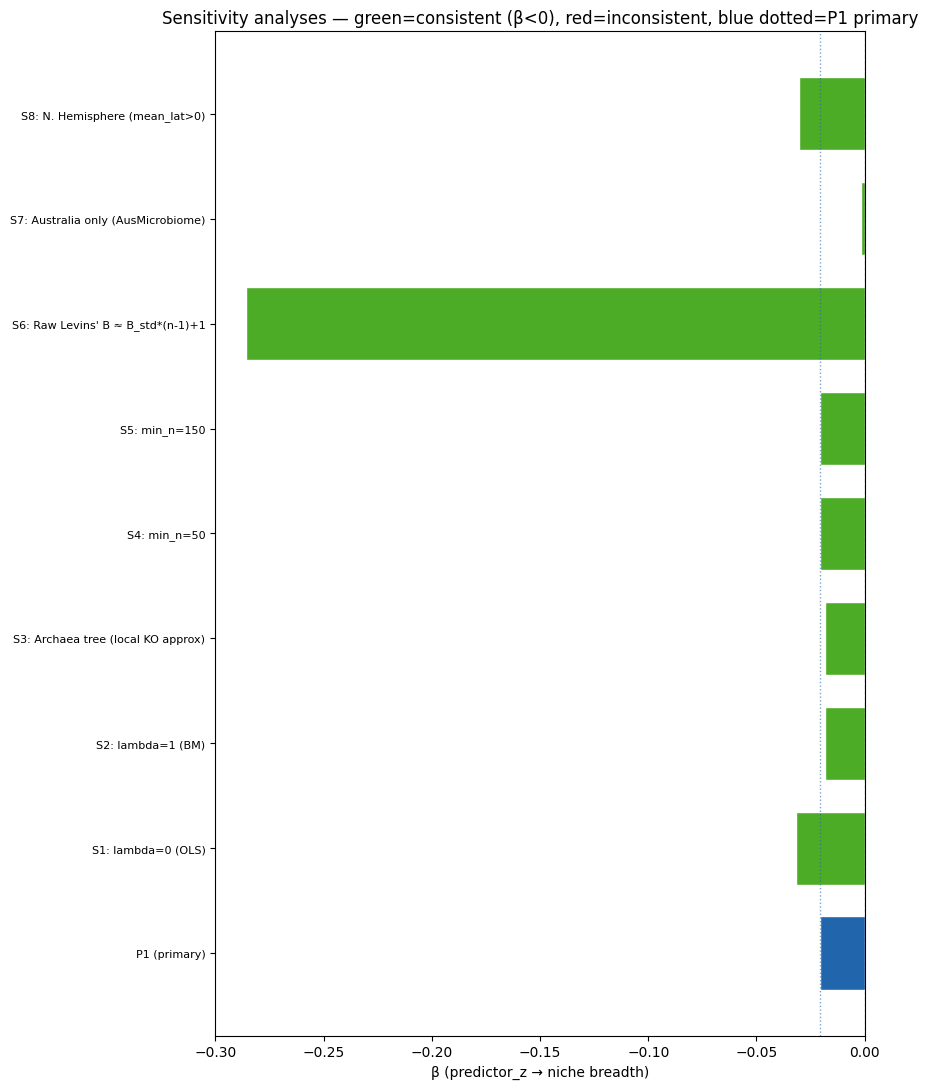

Saved: figures/05_sensitivity_beta_comparison.png

=== NB05 REPORTING SUMMARY ===
Primary β (P1): -0.02070
  S1: lambda=0 (OLS)                                 β=-0.03192  → CONSISTENT (β<0)
  S2: lambda=1 (BM)                                  β=-0.01824  → CONSISTENT (β<0)
  S3: Archaea tree (local KO approx)                 β=-0.01826  → CONSISTENT (β<0)
  S4: min_n=50                                       β=-0.02070  → CONSISTENT (β<0)
  S5: min_n=150                                      β=-0.02070  → CONSISTENT (β<0)
  S6: Raw Levins' B ≈ B_std*(n-1)+1                  β=-0.28583  → CONSISTENT (β<0)
  S7: Australia only (AusMicrobiome)                 β=-0.00171  → CONSISTENT (β<0)
  S8: N. Hemisphere (mean_lat>0)                     β=-0.03015  → CONSISTENT (β<0)

(Update INTERPRETATION_TABLE.md §6 with these results)


In [4]:
nb01_res = pd.read_csv(DATA / '01_primary_pgls_results.csv')
p1_row_s = nb01_res[nb01_res['label'].str.contains('P1', na=False)].iloc[0]
beta_p1 = float(p1_row_s['beta'])

sens_df_out = pgls_results_table(sens_results)
sens_df_out.to_csv(DATA / '05_sensitivity_results.csv', index=False)
print('Saved: data/05_sensitivity_results.csv')

fig, ax = plt.subplots(figsize=(9, max(4, len(sens_results) + 3)))
slabels = ['P1 (primary)'] + [f"{r.get('test','?')}: {r.get('condition','?')}" for r in sens_results]
sbetas  = [beta_p1] + [r.get('beta', float('nan')) for r in sens_results]
scolors = ['#2166ac'] + [
    '#4dac26' if (not np.isnan(b) and b < 0) else ('#d62728' if not np.isnan(b) else '#aaaaaa')
    for b in sbetas[1:]
]
ax.barh(range(len(sbetas)), sbetas, color=scolors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.axvline(beta_p1, color='#2166ac', lw=1.0, ls=':', alpha=0.6)
ax.set_yticks(range(len(slabels)))
ax.set_yticklabels(slabels, fontsize=8)
ax.set_xlabel('β (predictor_z → niche breadth)')
ax.set_title('Sensitivity analyses — green=consistent (β<0), red=inconsistent, blue dotted=P1 primary')
plt.tight_layout()
fig.savefig(FIGS / '05_sensitivity_beta_comparison.png', dpi=150)
plt.show()
print('Saved: figures/05_sensitivity_beta_comparison.png')

print('\n=== NB05 REPORTING SUMMARY ===')
print(f'Primary β (P1): {beta_p1:.5f}')
for r in sens_results:
    b = r.get('beta', float('nan'))
    cons = ('CONSISTENT (β<0)' if (not np.isnan(b) and b < 0)
            else ('INCONSISTENT (β≥0)' if not np.isnan(b) else 'N/A'))
    print(f"  {r.get('test','?')}: {str(r.get('condition','?'))[:45]:45s}  β={b:.5f}  → {cons}")
print('\n(Update INTERPRETATION_TABLE.md §6 with these results)')
